In [3]:
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — run '!pip install xgboost' if you want it included.")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset Loading

In [5]:
df = pd.read_csv("diabetes_prediction_dataset.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 2. Data Exploration (EDA)

In [6]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())
print(f"\nExact duplicate rows: {df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

Missing values per column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

E

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.03942,0.194593,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,NaN,NaN,NaN,5.527507,1.070672,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.05806,40.708136,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.278883,0.0,0.0,0.0,0.0,1.0


### 2.2 Target Variable Balance


diabetes
0    91500
1     8500
Name: count, dtype: int64

Positive class proportion: 8.50%


/tmp/ipykernel_1091/919072099.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diabetes', data=df, palette=['#4C72B0', '#C44E52'])


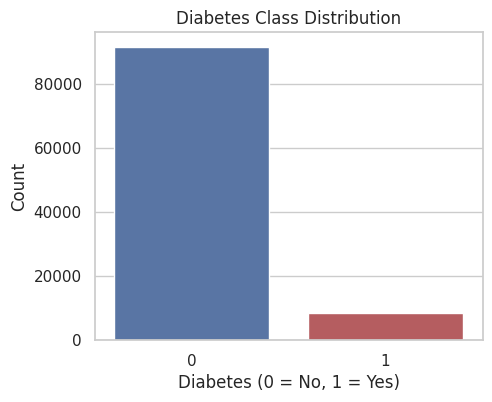

In [8]:
target_counts = df['diabetes'].value_counts()
print(target_counts)
print(f"\nPositive class proportion: {target_counts[1] / len(df):.2%}")

plt.figure(figsize=(5,4))
sns.countplot(x='diabetes', data=df, palette=['#4C72B0', '#C44E52'])
plt.title('Diabetes Class Distribution')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

### 2.3 Categorical Feature Breakdown

/tmp/ipykernel_1091/2086916233.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, ax=axes[0], palette='pastel')
/tmp/ipykernel_1091/2086916233.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='smoking_history', data=df, ax=axes[1],


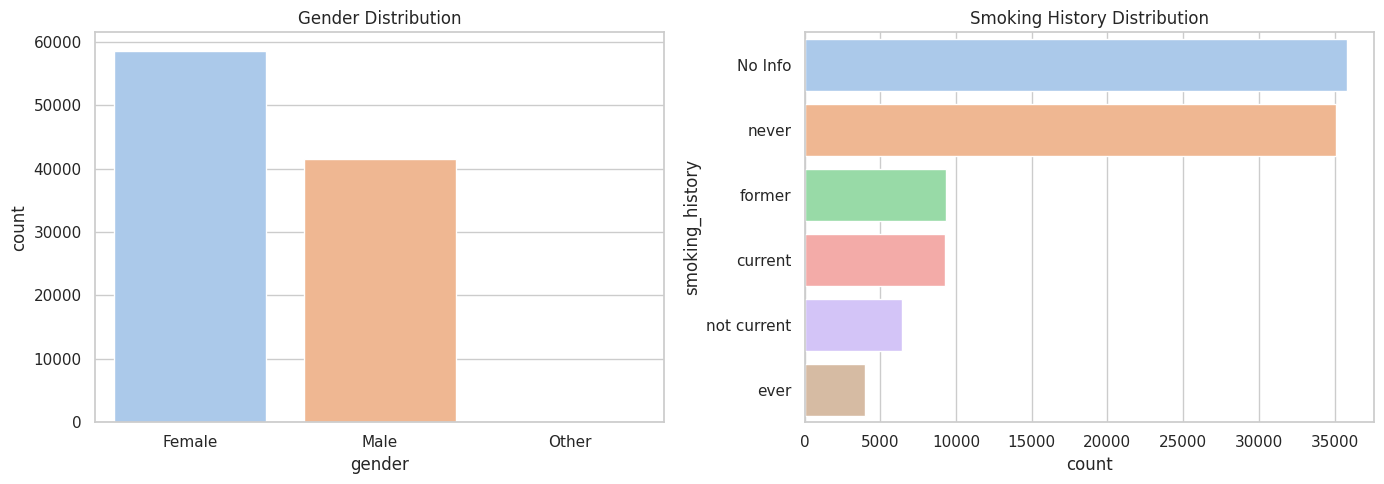

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='gender', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Gender Distribution')
sns.countplot(y='smoking_history', data=df, ax=axes[1],
              order=df['smoking_history'].value_counts().index, palette='pastel')
axes[1].set_title('Smoking History Distribution')
plt.tight_layout()
plt.show()

print(df['gender'].value_counts())
print()
print(df['smoking_history'].value_counts())

### 2.4 Numerical Feature Distributions

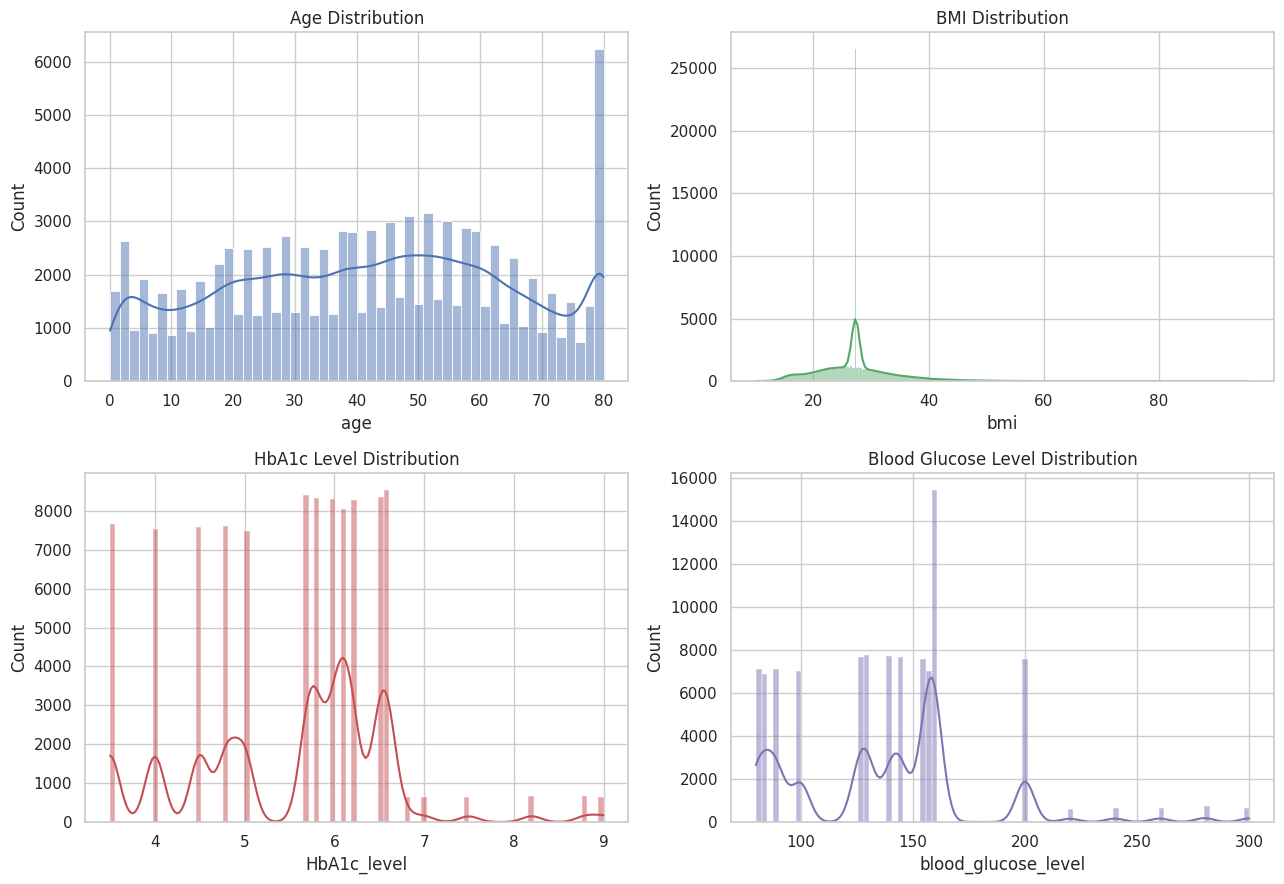

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(df['age'], kde=True, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Age Distribution')
sns.histplot(df['bmi'], kde=True, ax=axes[0,1], color='#55A868')
axes[0,1].set_title('BMI Distribution')
sns.histplot(df['HbA1c_level'], kde=True, ax=axes[1,0], color='#C44E52')
axes[1,0].set_title('HbA1c Level Distribution')
sns.histplot(df['blood_glucose_level'], kde=True, ax=axes[1,1], color='#8172B2')
axes[1,1].set_title('Blood Glucose Level Distribution')
plt.tight_layout()
plt.show()

### 2.5 Diabetes Prevalence by Key Factors

/tmp/ipykernel_1091/185364717.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hypertension', y='diabetes', data=df, ax=axes[0,0], palette='muted')
/tmp/ipykernel_1091/185364717.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='heart_disease', y='diabetes', data=df, ax=axes[0,1], palette='muted')
/tmp/ipykernel_1091/185364717.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='smoking_history', y='diabetes', data=df, ax=axes[1,0], palette='muted',


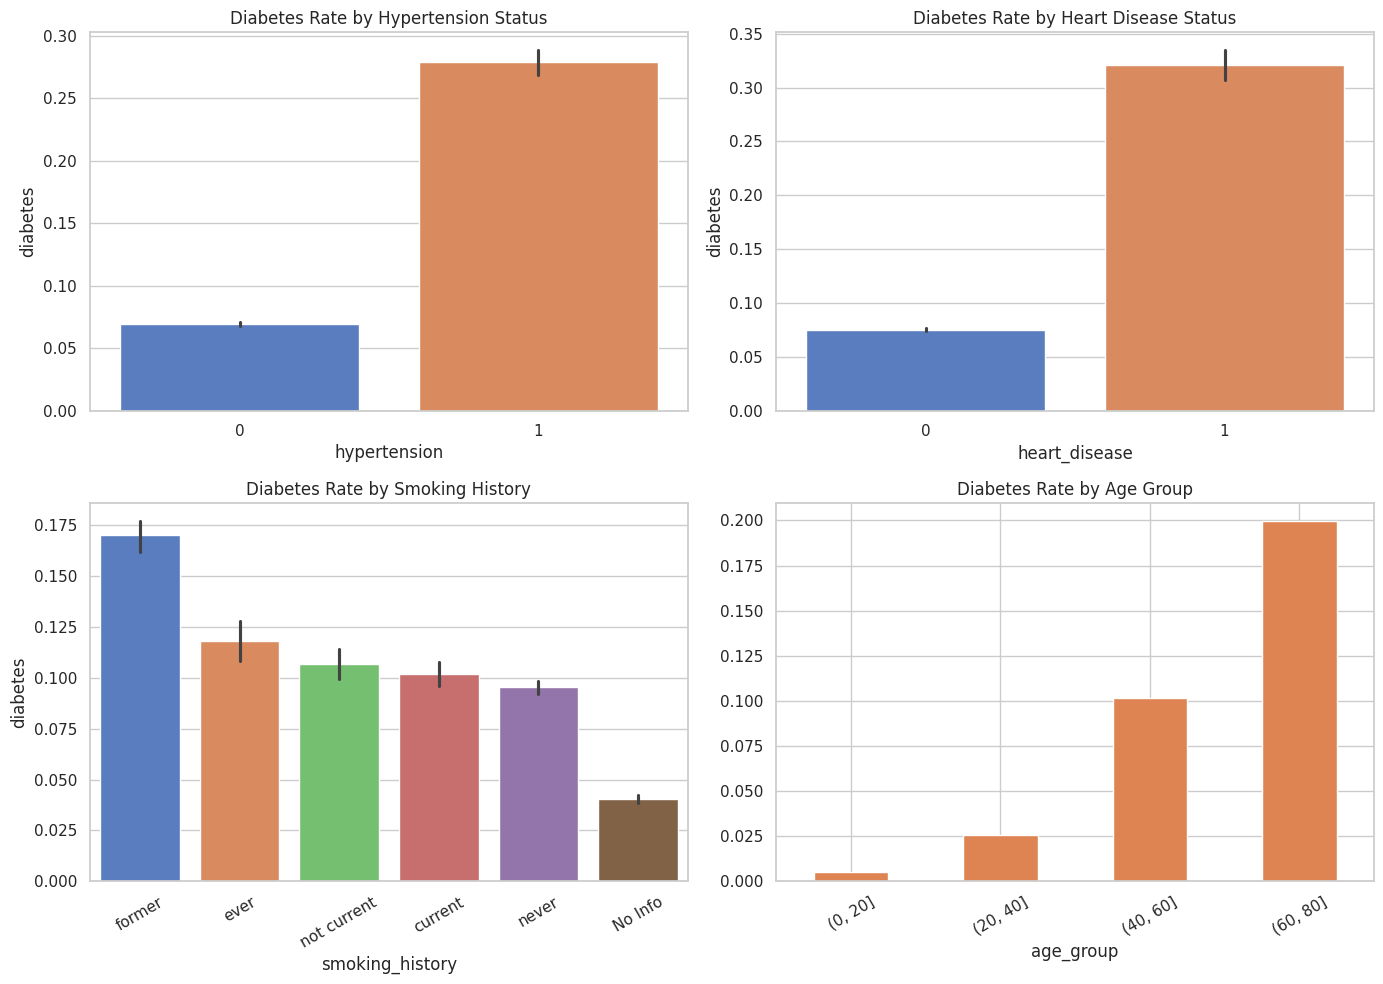

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x='hypertension', y='diabetes', data=df, ax=axes[0,0], palette='muted')
axes[0,0].set_title('Diabetes Rate by Hypertension Status')

sns.barplot(x='heart_disease', y='diabetes', data=df, ax=axes[0,1], palette='muted')
axes[0,1].set_title('Diabetes Rate by Heart Disease Status')

sns.barplot(x='smoking_history', y='diabetes', data=df, ax=axes[1,0], palette='muted',
            order=df.groupby('smoking_history')['diabetes'].mean().sort_values(ascending=False).index)
axes[1,0].set_title('Diabetes Rate by Smoking History')
axes[1,0].tick_params(axis='x', rotation=30)

age_bins = pd.cut(df['age'], bins=[0,20,40,60,80,100])
df.assign(age_group=age_bins).groupby('age_group', observed=True)['diabetes'].mean().plot(
    kind='bar', ax=axes[1,1], color='#DD8452')
axes[1,1].set_title('Diabetes Rate by Age Group')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 2.6 Correlation Heatmap (numeric features)

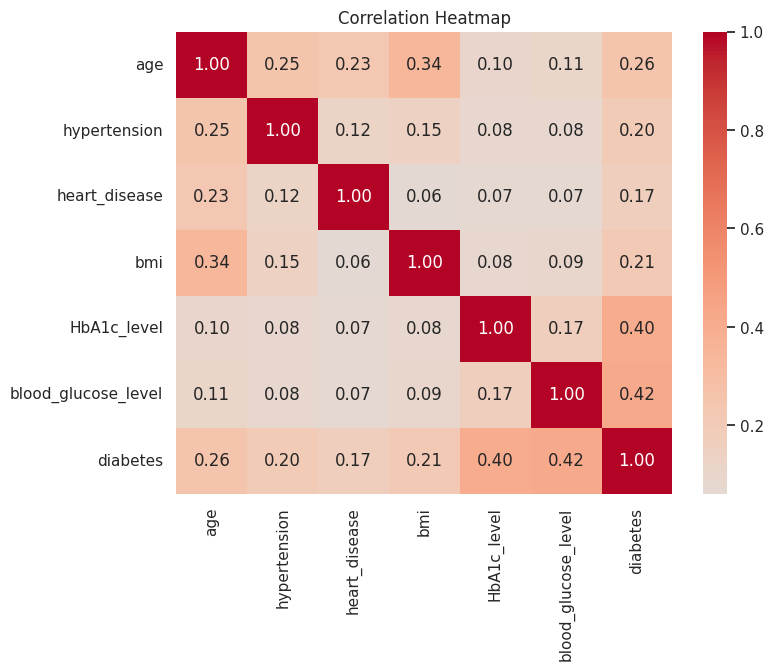

In [12]:
numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
                'blood_glucose_level', 'diabetes']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

## 3. Data Cleaning

In [13]:
df_clean = df.copy()


before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean)} duplicate rows ({(before-len(df_clean))/before:.1%})")


before = len(df_clean)
df_clean = df_clean[df_clean['gender'] != 'Other']
print(f"Removed {before - len(df_clean)} 'Other' gender rows")

print(f"\nFinal cleaned shape: {df_clean.shape}")

Removed 3854 duplicate rows (3.9%)
Removed 18 'Other' gender rows

Final cleaned shape: (96128, 9)


## 4. Preprocessing

In [14]:
df_model = df_clean.copy()


df_model['gender'] = df_model['gender'].map({'Female': 0, 'Male': 1})


df_model = pd.get_dummies(df_model, columns=['smoking_history'], prefix='smoke', drop_first=True)

X = df_model.drop(columns=['diabetes'])
y = df_model['diabetes']

print(X.columns.tolist())
X.head()

['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'smoke_current', 'smoke_ever', 'smoke_former', 'smoke_never', 'smoke_not current']


,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,smoke_current,smoke_ever,smoke_former,smoke_never,smoke_not current
0,0,80.0,0,1,25.19,6.6,140,False,False,False,True,False
1,0,54.0,0,0,27.32,6.6,80,False,False,False,False,False
2,1,28.0,0,0,27.32,5.7,158,False,False,False,True,False
3,0,36.0,0,0,23.45,5.0,155,True,False,False,False,False
4,1,76.0,1,1,20.14,4.8,155,True,False,False,False,False


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")

Train shape: (76902, 12), Test shape: (19226, 12)
Train class balance:
diabetes
0    0.911758
1    0.088242
Name: proportion, dtype: float64


## 5. Model Training (using 5 different algorithms)

In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                             max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
}

if HAS_XGB:
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1
    )

results = {}
trained_models = {}

for name, model in models.items():
    if name == 'SVM (RBF)':

        X_sub, _, y_sub, _ = train_test_split(X_train_scaled, y_train, train_size=8000,
                                               stratify=y_train, random_state=RANDOM_STATE)
        model.fit(X_sub, y_sub)
    elif name in ['KNN']:
        model.fit(X_train_scaled, y_train)
    elif name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: KNN
Trained: SVM (RBF)
Trained: XGBoost


## 6. Model Evaluation

In [17]:
def evaluate(name, model, X_te, X_te_scaled):
    X_input = X_te_scaled if name in ['Logistic Regression', 'KNN', 'SVM (RBF)'] else X_te
    y_pred = model.predict(X_input)
    y_proba = model.predict_proba(X_input)[:, 1]

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    }, y_pred, y_proba

eval_results = {}
predictions = {}
probabilities = {}

for name, model in trained_models.items():
    metrics, y_pred, y_proba = evaluate(name, model, X_test, X_test_scaled)
    eval_results[name] = metrics
    predictions[name] = y_pred
    probabilities[name] = y_proba

results_df = pd.DataFrame(eval_results).T.sort_values('ROC-AUC', ascending=False)
results_df.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost,0.9073,0.4862,0.8956,0.6303,0.9763
Random Forest,0.9060,0.4821,0.8886,0.6251,0.9742
Decision Tree,0.8855,0.4294,0.9057,0.5826,0.9709
Logistic Regression,0.8853,0.4269,0.8762,0.5741,0.9596
SVM (RBF),0.9045,0.4770,0.8561,0.6127,0.9503
KNN,0.9601,0.9540,0.5749,0.7174,0.9420


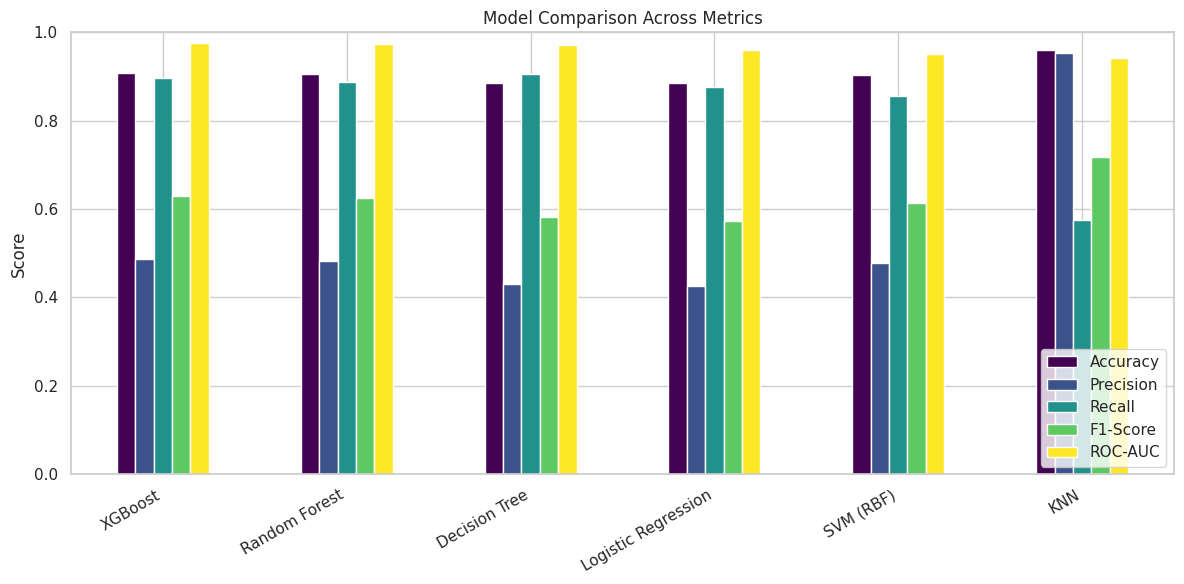

In [18]:
results_df[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']].plot(
    kind='bar', figsize=(12,6), colormap='viridis')
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

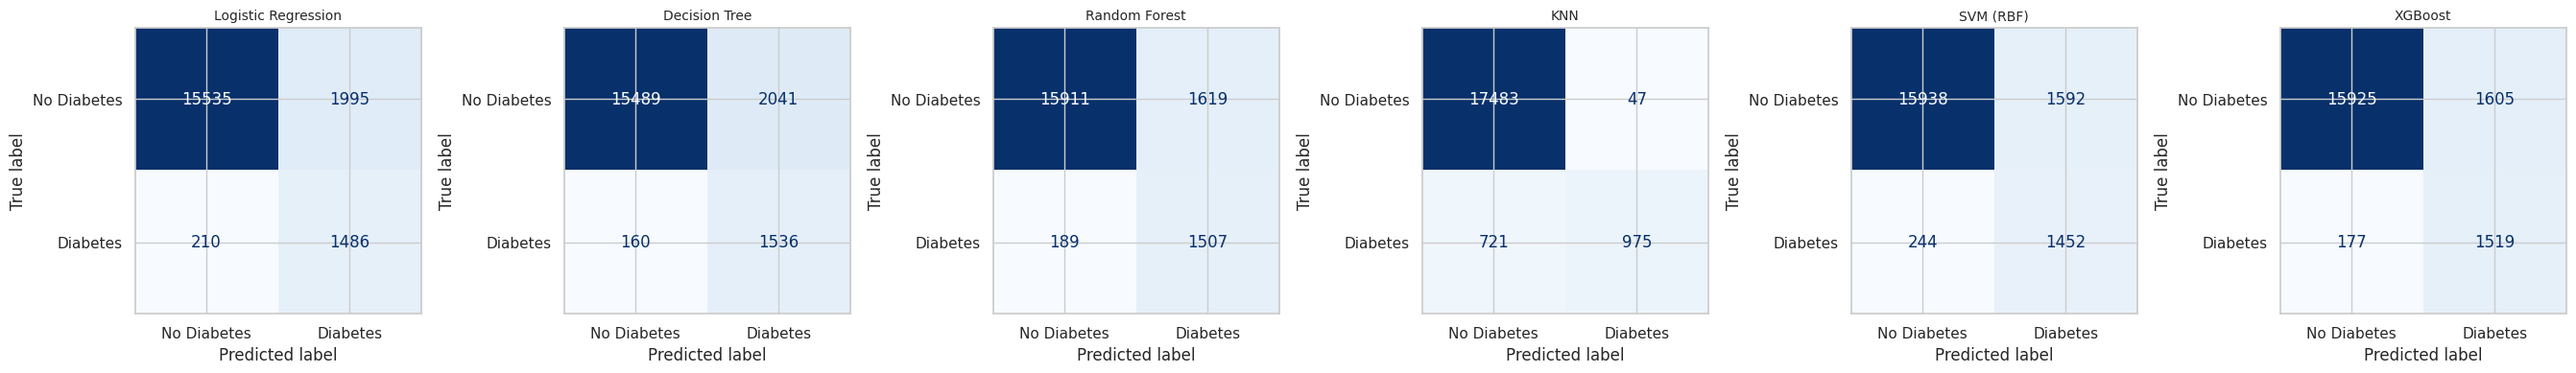

In [19]:
n_models = len(trained_models)
fig, axes = plt.subplots(1, n_models, figsize=(4.5*n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()

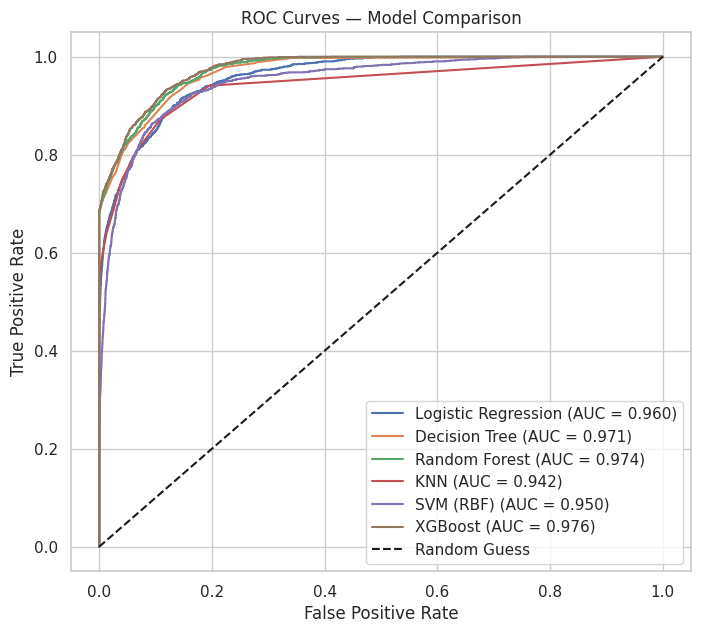

In [20]:
plt.figure(figsize=(8, 7))
for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.show()

## 7. Hyperparameter Tuning



In [21]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, None],
    'min_samples_split': [2, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
tuned_metrics, tuned_pred, tuned_proba = evaluate('Random Forest', best_rf, X_test, X_test_scaled)
print("\nTuned Random Forest test performance:")
for k, v in tuned_metrics.items():
    print(f"  {k}: {v:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': 12, 'min_samples_split': 10, 'n_estimators': 200}
Best CV ROC-AUC: 0.9764

Tuned Random Forest test performance:
  Accuracy: 0.9055
  Precision: 0.4807
  Recall: 0.8892
  F1-Score: 0.6240
  ROC-AUC: 0.9746


/tmp/ipykernel_1091/104381182.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


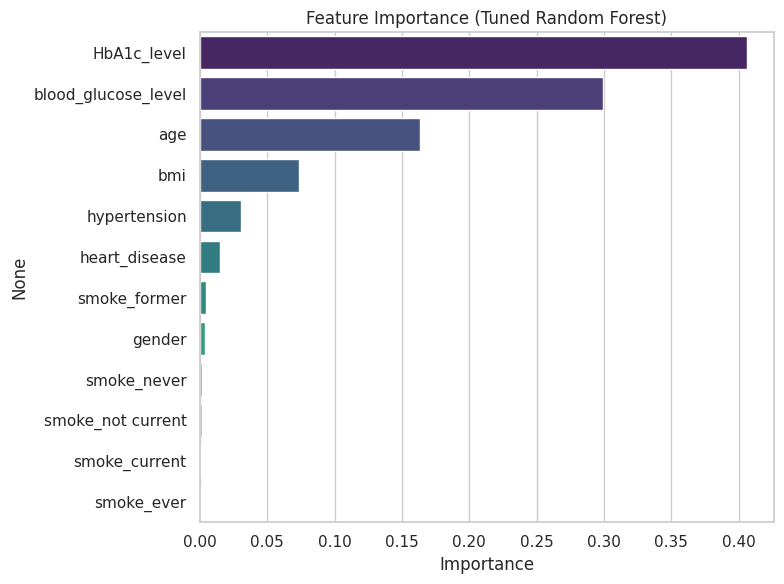

,0
HbA1c_level,0.405924
blood_glucose_level,0.299508
age,0.163386
bmi,0.073306
hypertension,0.030415
heart_disease,0.015064
smoke_former,0.004227
gender,0.003580
smoke_never,0.001468
smoke_not current,0.001264


In [22]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance (Tuned Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances

/tmp/ipykernel_1091/3346757467.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_importances.values, y=perm_importances.index, palette='magma')


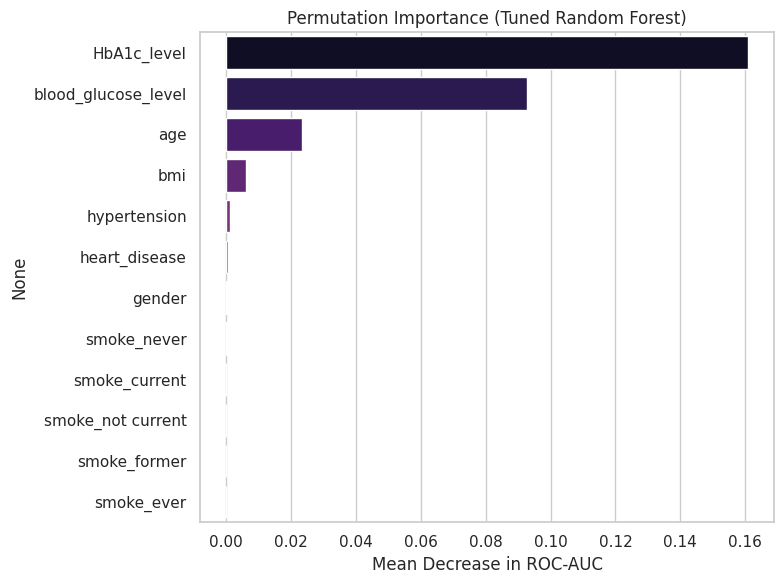

,0
HbA1c_level,0.160861
blood_glucose_level,0.092657
age,0.023325
bmi,0.006162
hypertension,0.001088
heart_disease,0.000596
gender,0.000210
smoke_never,0.000090
smoke_current,0.000025
smoke_not current,-0.000034


In [23]:
perm_result = permutation_importance(best_rf, X_test, y_test, n_repeats=10,
                                      random_state=RANDOM_STATE, n_jobs=-1, scoring='roc_auc')

perm_importances = pd.Series(perm_result.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=perm_importances.values, y=perm_importances.index, palette='magma')
plt.title('Permutation Importance (Tuned Random Forest)')
plt.xlabel('Mean Decrease in ROC-AUC')
plt.tight_layout()
plt.show()

perm_importances